In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Problem Statement for Regression:

Objective:
- Predict the charges (health insurance charges) of individuals based on various factors like age, sex, BMI, number of children, smoking status, and region.

Target Variable:

charges (dependent variable)

Features:

- age: Age of the individual.
- sex: Gender (male, female).
- bmi: Body Mass Index (BMI).
- children: Number of children/dependents.
- smoker: Whether the individual is a smoker (yes, no).
- region: Geographical region (e.g., southwest, southeast, northwest, northeast).

In [3]:
df = pd.read_csv(r"C:\Users\SHRI\OneDrive\Desktop\DataScience_DataFiles\ML_data\Medical Insurance Costs Dataset.csv")

# Data Understanding

In [4]:
df

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
...,...,...,...,...,...,...,...
2767,47,female,45.320,1,no,southeast,8569.86180
2768,21,female,34.600,0,no,southwest,2020.17700
2769,19,male,26.030,1,yes,northwest,16450.89470
2770,23,male,18.715,0,no,northwest,21595.38229


In [5]:
df.shape

(2772, 7)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2772 entries, 0 to 2771
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       2772 non-null   int64  
 1   sex       2772 non-null   object 
 2   bmi       2772 non-null   float64
 3   children  2772 non-null   int64  
 4   smoker    2772 non-null   object 
 5   region    2772 non-null   object 
 6   charges   2772 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 151.7+ KB


In [7]:
df.columns.tolist()

['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

All columns in correct syntax

In [8]:
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

No null values present in the dataset

In [9]:
df.dtypes

age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

# Exploratory data analysis

All dtypes are correctly mention

In [10]:
df.describe()

,age,bmi,children,charges
count,2772.000000,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,1.101732,13261.369959
std,14.081459,6.129449,1.214806,12151.768945
min,18.000000,15.960000,0.000000,1121.873900
25%,26.000000,26.220000,0.000000,4687.797000
50%,39.000000,30.447500,1.000000,9333.014350
75%,51.000000,34.770000,2.000000,16577.779500
max,64.000000,53.130000,5.000000,63770.428010


In [11]:
d = df.nunique()
d 

age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [12]:
continous = ['age', 'bmi', 'charges']

count = ['children']

categorical = ['sex', 'smoker', 'region']


In [13]:
df[continous].describe()

,age,bmi,charges
count,2772.000000,2772.000000,2772.000000
mean,39.109668,30.701349,13261.369959
std,14.081459,6.129449,12151.768945
min,18.000000,15.960000,1121.873900
25%,26.000000,26.220000,4687.797000
50%,39.000000,30.447500,9333.014350
75%,51.000000,34.770000,16577.779500
max,64.000000,53.130000,63770.428010


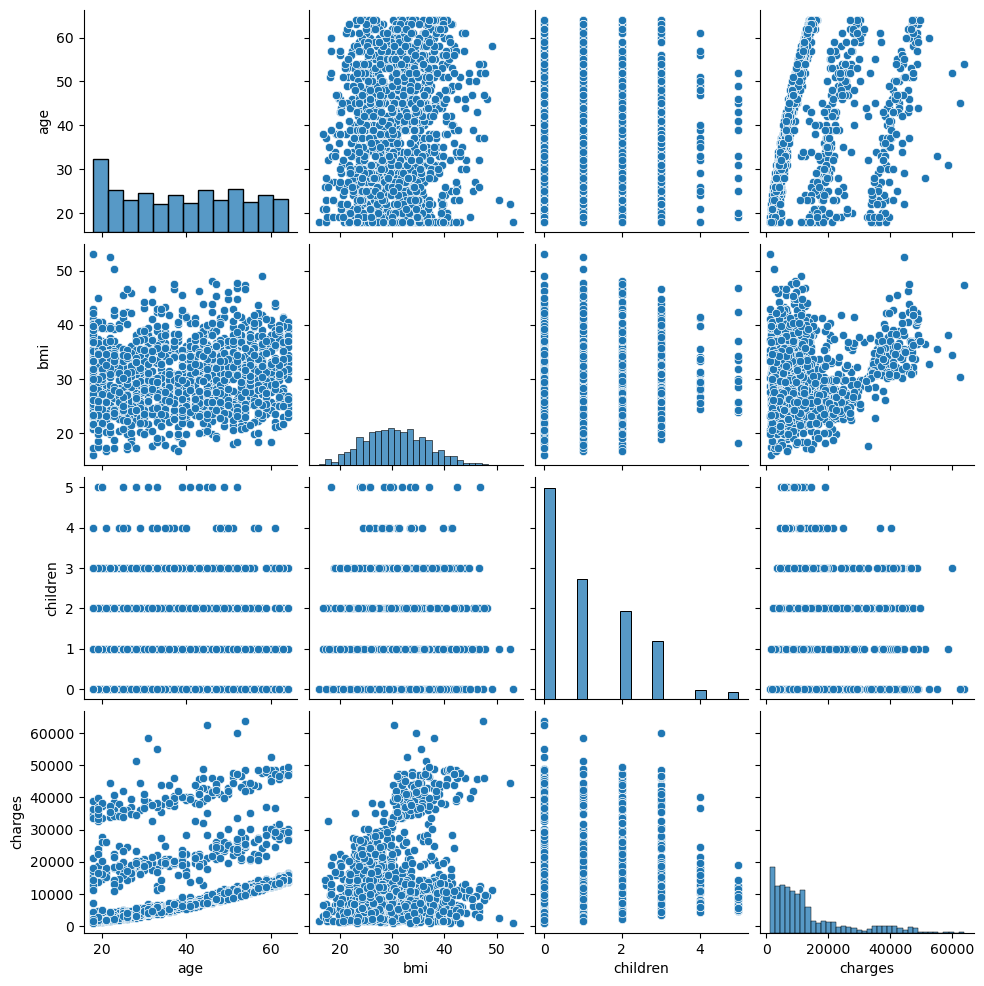

In [14]:
sns.pairplot(df)
plt.show()

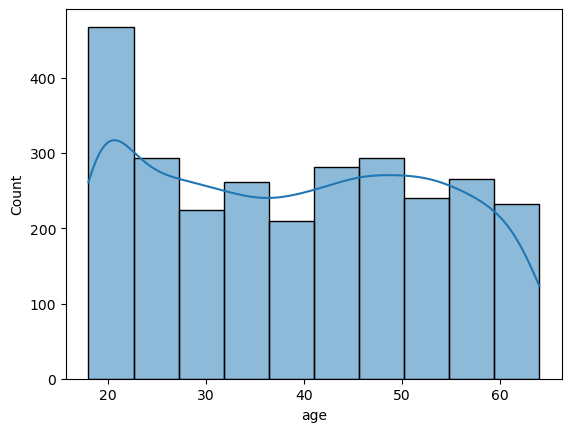

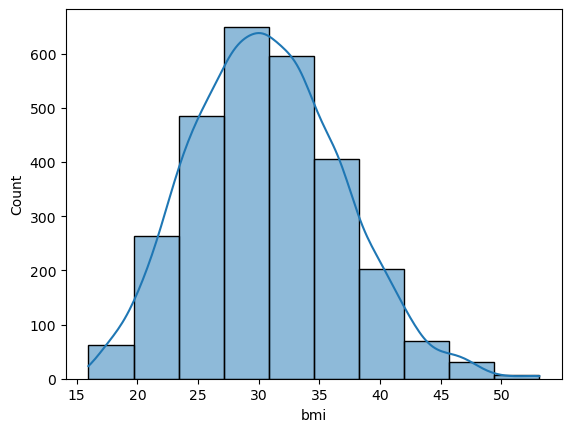

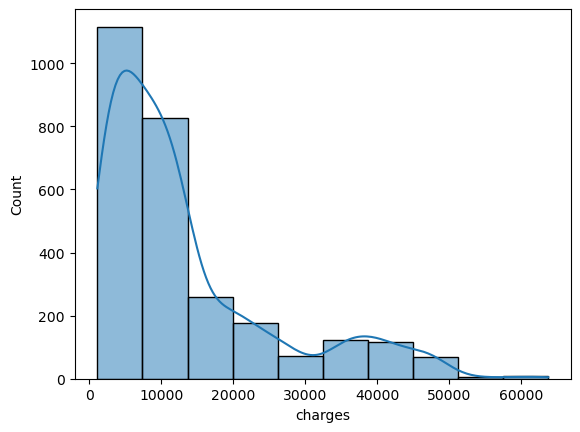

In [15]:
for i  in continous:
    sns.histplot( df[i], bins = 10, kde = True)
    plt.show()

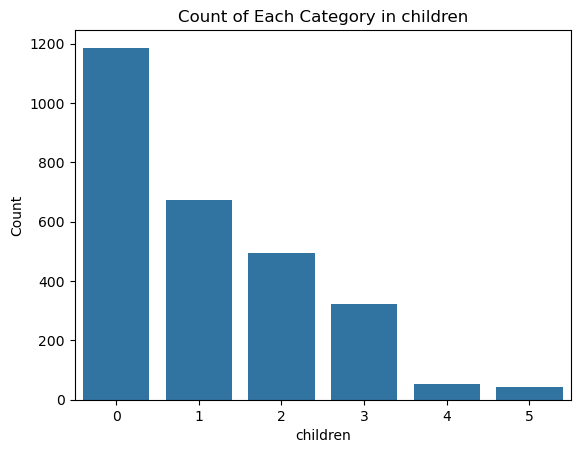

In [16]:
sns.countplot(data=df, x='children')  # Change 'sex' to any categorical column
plt.title('Count of Each Category in children')
plt.xlabel('children')
plt.ylabel('Count')
plt.show()

In [17]:
for i in df.columns:
    print(i, df[i].unique())
    print("------------------------------------")

age [19 18 28 33 32 31 46 37 60 25 62 23 56 27 52 30 34 59 63 55 22 26 35 24
 41 38 36 21 48 40 58 53 43 64 20 61 44 57 29 45 54 49 47 51 42 50 39]
------------------------------------
sex ['female' 'male']
------------------------------------
bmi [27.9   33.77  33.    22.705 28.88  25.74  33.44  27.74  29.83  25.84
 26.22  26.29  34.4   39.82  42.13  24.6   30.78  23.845 40.3   35.3
 36.005 32.4   34.1   31.92  28.025 27.72  23.085 32.775 17.385 36.3
 35.6   26.315 28.6   28.31  36.4   20.425 32.965 20.8   36.67  39.9
 26.6   36.63  21.78  30.8   37.05  37.3   38.665 34.77  24.53  35.2
 35.625 33.63  28.    34.43  28.69  36.955 31.825 31.68  22.88  37.335
 27.36  33.66  24.7   25.935 22.42  28.9   39.1   36.19  23.98  24.75
 28.5   28.1   32.01  27.4   34.01  29.59  35.53  39.805 26.885 38.285
 37.62  41.23  34.8   22.895 31.16  27.2   26.98  39.49  24.795 31.3
 38.28  19.95  19.3   31.6   25.46  30.115 29.92  27.5   28.4   30.875
 27.94  35.09  29.7   35.72  32.205 28.595 49.06  27.1

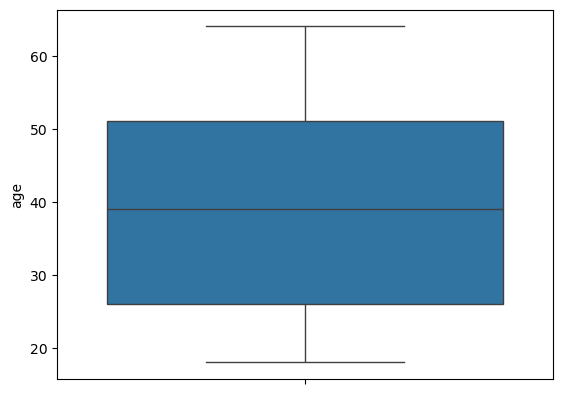

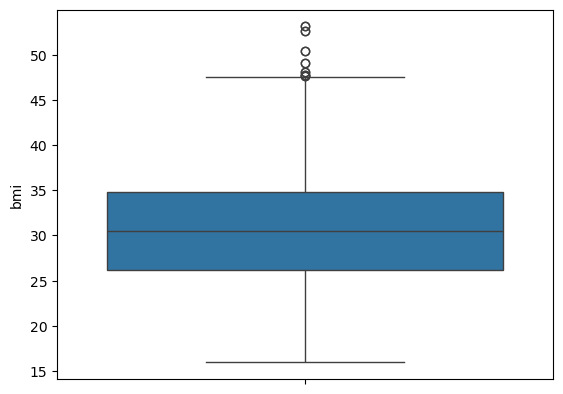

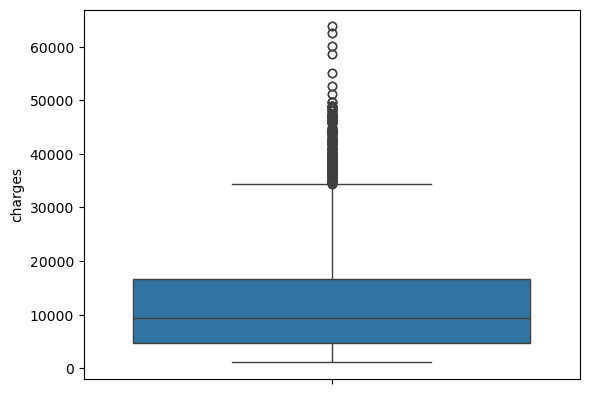

In [18]:
for i in continous:
    sns.boxplot(df[i])
    plt.show()

**check whether there is any wrong value enterd**

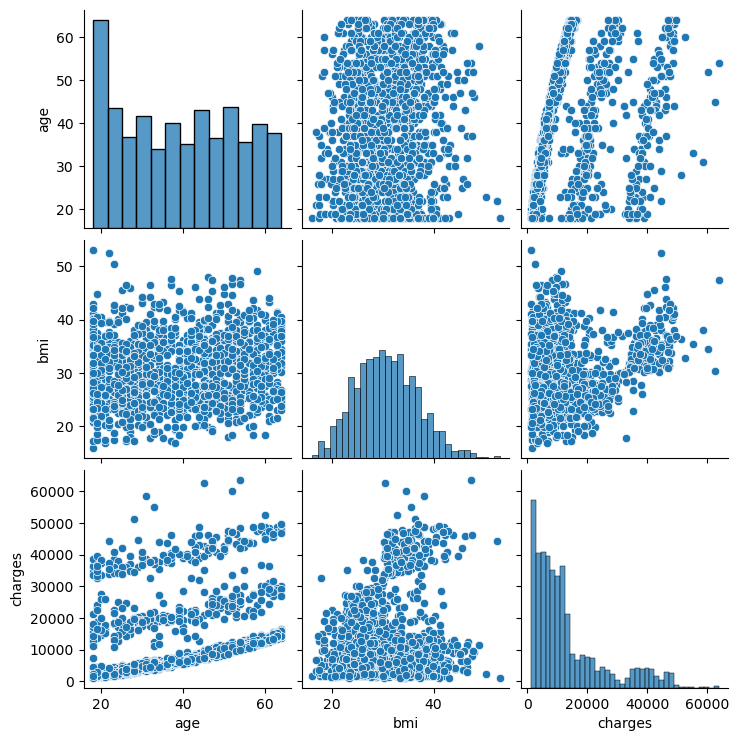

In [19]:
sns.pairplot(df[continous])
plt.show()

In [20]:
df[(df['charges'] < df['charges'].min()) | (df['charges'] > df['charges'].max())]

,age,sex,bmi,children,smoker,region,charges


In [21]:
df[(df['age'] < df['age'].min()) | (df['age'] > df['age'].max())]

,age,sex,bmi,children,smoker,region,charges


In [22]:
df[(df['bmi'] < df['bmi'].min()) | (df['bmi'] > df['bmi'].max())]

,age,sex,bmi,children,smoker,region,charges


In [23]:
df[continous].skew()

age        0.061639
bmi        0.279944
charges    1.511315
dtype: float64

- Skewness value of 1.51 indicates a positively skewed distribution (right skew).


<Axes: xlabel='charges', ylabel='Density'>

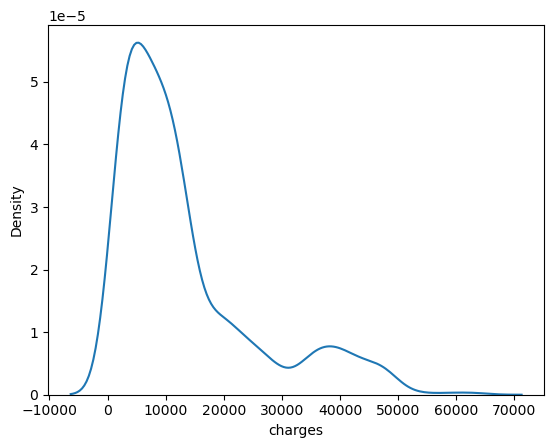

In [24]:
sns.kdeplot(df['charges'])

In [25]:
for i in categorical:
    print(df[i].value_counts())
    print('====================')

sex
male      1406
female    1366
Name: count, dtype: int64
smoker
no     2208
yes     564
Name: count, dtype: int64
region
southeast    766
southwest    684
northwest    664
northeast    658
Name: count, dtype: int64


**Observations:**

- Sex: The dataset has a balanced distribution, with 1406 males and 1366 females.
- Smoker: Most individuals are non-smokers (2208), with 564 smokers.
- Region: The regions are fairly balanced, with slight variation:
- - Southeast: 766
- - Southwest: 684
- - Northwest: 664
- - Northeast: 658

Missing Values: There are no null values in some columns, but a few columns (like floor, transaction, furnishing, facing, and description) have missing data. You can handle these missing values by either imputing or dropping them based on your analysis needs.

Data Types: Columns like price, price_sqft, and charges are in object/string format, but they should be numerical for analysis. You will need to convert these columns to the appropriate numeric data type.

Unique Values: The categorical columns like sex, smoker, and region have a reasonable distribution of values. For instance, sex is balanced, smoker has more non-smokers, and region is fairly even across the four regions.

Outliers: The dataset might have some outliers, particularly in the charges column, as seen from the extreme values (which can be checked further using statistical methods or visualizations like box plots).

Consistency: Columns such as children, bmi, and charges look consistent, but price and price_sqft columns need to be converted and cleaned for proper analysis.

Overall, the dataset is mostly clean, but some transformations (like handling missing values, correcting data types, and checking for outliers) are required before you can proceed with regression modeling.

In [27]:
df.duplicated().sum()

1435

In [28]:
# Removing duplicated records in data preprocessing